<a href="https://colab.research.google.com/github/iiiyahiya111/Project/blob/main/week_3_0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Cell 1: Setup, Ingestion, & Path Reconstruction**

In [1]:
import os
import random
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

print("Dependencies re-imported successfully.")

Dependencies re-imported successfully.


In [3]:
# ============================================================
# WEEK-3 | INSTALL + IMPORTS + DATASET PREPARATION
# ============================================================

# Install required libraries
!pip -q install "albumentations>=2.0.0" scikit-learn scipy pandas matplotlib seaborn tqdm


# ------------------------------------------------------------
# Imports
# ------------------------------------------------------------
import os
import random
import zipfile
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from scipy.stats import pearsonr, spearmanr

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from torchvision.models import (
    resnet50,
    ResNet50_Weights,
    efficientnet_b0,
    EfficientNet_B0_Weights
)

import albumentations as A
from albumentations.pytorch import ToTensorV2

from google.colab import drive


# ============================================================
# 1. Reproducibility
# ============================================================

SEED = 42

def seed_everything(seed=42):

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    os.environ["PYTHONHASHSEED"] = str(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything(SEED)


# ============================================================
# 2. Mount Google Drive
# ============================================================

drive.mount("/content/drive")


# ============================================================
# 3. Locate Dataset ZIP in Google Drive
# ============================================================

DRIVE_ROOT = Path("/content/drive/MyDrive")

ZIP_NAME = "Potato_Severity_Dataset_DEDUPED_FINAL.zip"

# Search inside MyDrive so you don't need to hard-code
# a folder such as /MyDrive/Research/... etc.
zip_candidates = list(DRIVE_ROOT.rglob(ZIP_NAME))

if len(zip_candidates) == 0:
    raise FileNotFoundError(
        f"Could not find '{ZIP_NAME}' inside Google Drive.\n"
        f"Please upload/copy the ZIP to MyDrive."
    )

if len(zip_candidates) > 1:
    print("Multiple ZIP files found:")
    for p in zip_candidates:
        print(" -", p)

    raise RuntimeError(
        "Multiple copies of the dataset ZIP were found. "
        "Keep only one copy or set ZIP_PATH manually."
    )

ZIP_PATH = zip_candidates[0]

print("Dataset ZIP:")
print(ZIP_PATH)


# ============================================================
# 4. Extract ZIP to Colab Local Storage
# ============================================================

EXTRACT_ROOT = Path("/content/potato_week3")

if EXTRACT_ROOT.exists():
    shutil.rmtree(EXTRACT_ROOT)

EXTRACT_ROOT.mkdir(
    parents=True,
    exist_ok=True
)

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    z.extractall(EXTRACT_ROOT)

print("\nExtracted to:")
print(EXTRACT_ROOT)


# ============================================================
# 5. Locate Dataset Root Automatically
# ============================================================

CSV_RELATIVE_PATH = (
    "severity_dataset/potato_severity_FINAL.csv"
)

csv_candidates = list(
    EXTRACT_ROOT.glob(
        f"**/{CSV_RELATIVE_PATH}"
    )
)

if len(csv_candidates) == 0:
    raise FileNotFoundError(
        "potato_severity_FINAL.csv was not found "
        "inside the extracted dataset."
    )

if len(csv_candidates) > 1:
    raise RuntimeError(
        "Multiple copies of potato_severity_FINAL.csv found."
    )

CSV_PATH = csv_candidates[0]

DATASET_ROOT = CSV_PATH.parent.parent

print("\nDataset root:")
print(DATASET_ROOT)

print("\nCSV path:")
print(CSV_PATH)


# ============================================================
# 6. Read CSV
# ============================================================

df = pd.read_csv(CSV_PATH)

print("\nDataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())


# ============================================================
# 7. Basic Dataset Sanity Checks
# ============================================================

assert len(df) == 1108, (
    f"Expected 1108 samples, found {len(df)}"
)

expected_split_counts = {
    "train": 895,
    "valid": 107,
    "test": 106
}

actual_split_counts = (
    df["split"]
    .value_counts()
    .to_dict()
)

assert actual_split_counts == expected_split_counts, (
    f"Unexpected split counts:\n"
    f"{actual_split_counts}"
)

print("\nSplit distribution:")
print(df["split"].value_counts())

print("\nClass distribution:")
print(df["class_name"].value_counts())


# ============================================================
# 8. Rebuild Correct Dataset Paths
# ============================================================

def build_paths(row):

    split = row["split"]
    filename = row["filename"]

    stem = Path(filename).stem

    # RGB image
    image_path = (
        DATASET_ROOT
        / "segmentation"
        / split
        / "images"
        / filename
    )

    # Leaf mask
    leaf_mask_path = (
        DATASET_ROOT
        / "segmentation"
        / split
        / "leaf_masks"
        / f"{stem}_leaf.png"
    )

    # IMPORTANT:
    # Actual lesion mask filename is:
    #     <image_stem>.png
    # NOT:
    #     <image_stem>_lesion.png
    lesion_mask_path = (
        DATASET_ROOT
        / "segmentation"
        / split
        / "lesion_masks"
        / f"{stem}.png"
    )

    return pd.Series({
        "image_file": str(image_path),
        "leaf_mask_file": str(leaf_mask_path),
        "lesion_mask_file": str(lesion_mask_path)
    })


paths = df.apply(
    build_paths,
    axis=1
)

df = pd.concat(
    [df, paths],
    axis=1
)


# ============================================================
# 9. Verify All Image / Mask Files
# ============================================================

df["image_exists"] = (
    df["image_file"]
    .apply(os.path.exists)
)

df["leaf_exists"] = (
    df["leaf_mask_file"]
    .apply(os.path.exists)
)

df["lesion_exists"] = (
    df["lesion_mask_file"]
    .apply(os.path.exists)
)

print("\nMissing files:")
print("Images      :", (~df["image_exists"]).sum())
print("Leaf masks  :", (~df["leaf_exists"]).sum())
print("Lesion masks:", (~df["lesion_exists"]).sum())


assert df["image_exists"].all(), (
    "Some image files are missing."
)

assert df["leaf_exists"].all(), (
    "Some leaf mask files are missing."
)

assert df["lesion_exists"].all(), (
    "Some lesion mask files are missing."
)


# ============================================================
# 10. Create Train / Validation / Test DataFrames
# ============================================================

train_df = (
    df[df["split"] == "train"]
    .reset_index(drop=True)
)

val_df = (
    df[df["split"] == "valid"]
    .reset_index(drop=True)
)

test_df = (
    df[df["split"] == "test"]
    .reset_index(drop=True)
)


# ============================================================
# 11. Final Preparation Summary
# ============================================================

print("\n" + "=" * 60)
print("DATASET READY FOR WEEK-3 EXPERIMENTS")
print("=" * 60)

print(f"Train      : {len(train_df)}")
print(f"Validation : {len(val_df)}")
print(f"Test       : {len(test_df)}")

print("\nAll image, leaf-mask and lesion-mask files verified.")
print("Dataset preparation completed successfully.")

Mounted at /content/drive
Dataset ZIP:
/content/drive/MyDrive/Potato_Severity_Dataset_DEDUPED_FINAL.zip

Extracted to:
/content/potato_week3

Dataset root:
/content/potato_week3/Potato_Severity_Dataset_FINAL

CSV path:
/content/potato_week3/Potato_Severity_Dataset_FINAL/severity_dataset/potato_severity_FINAL.csv

Dataset shape: (1108, 24)

Columns:
['split', 'filename', 'class_name', 'image_path', 'lesion_mask_path', 'leaf_mask_path', 'overlay_path', 'combined_path', 'severity_percent', 'leaf_pixels', 'lesion_pixels', 'lesion_inside_leaf', 'lesion_outside_leaf', 'leaf_area_ratio', 'shadow_pixels_detected', 'shadow_pixels_after_close', 'shadow_pixels_removed', 'shadow_removed_ratio', 'shadow_components_total', 'shadow_components_removed', 'qc_status', 'qc_flags', 'final_decision', 'manual_reject_reason']

Split distribution:
split
train    895
valid    107
test     106
Name: count, dtype: int64

Class distribution:
class_name
Potato Late Blight    563
Potato Healthy        545
Name: cou

# **Cell 2: Configurations, Augmentations, & Dataset Pipeline**

In [4]:
# Global Hyperparameters
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 0
EPOCHS = 30
PATIENCE = 7
LR = 1e-4
WEIGHT_DECAY = 1e-4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

# Augmentations
def get_val_transform():
    return A.Compose([
        A.Resize(IMG_SIZE, IMG_SIZE),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2()
    ])

def get_no_aug_transform():
    return get_val_transform()

def get_geometric_transform():
    return A.Compose([
        A.Resize(IMG_SIZE, IMG_SIZE),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.2),
        A.Rotate(limit=15, border_mode=cv2.BORDER_REFLECT_101, p=0.5),
        A.Affine(scale=(0.95, 1.05), translate_percent=(-0.03, 0.03), rotate=(-5, 5), shear=(-3, 3), p=0.3),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2()
    ])

def get_full_train_transform():
    return A.Compose([
        A.Resize(IMG_SIZE, IMG_SIZE),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.2),
        A.Rotate(limit=15, border_mode=cv2.BORDER_REFLECT_101, p=0.5),
        A.Affine(scale=(0.95, 1.05), translate_percent=(-0.03, 0.03), rotate=(-5, 5), shear=(-3, 3), p=0.3),
        A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.4),
        A.HueSaturationValue(hue_shift_limit=8, sat_shift_limit=10, val_shift_limit=8, p=0.3),
        A.GaussNoise(std_range=(0.01, 0.03), p=0.15),
        A.OneOf([A.GaussianBlur(blur_limit=(3, 5)), A.MotionBlur(blur_limit=3)], p=0.10),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2()
    ])

# Dataset Class
class PotatoSeverityDataset(Dataset):
    def __init__(self, dataframe, transform=None, leaf_masked=False):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.leaf_masked = leaf_masked

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = cv2.imread(row["image_file"])
        if image is None: raise FileNotFoundError(row["image_file"])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        leaf_mask = cv2.imread(row["leaf_mask_file"], cv2.IMREAD_GRAYSCALE)
        if leaf_mask is None: raise FileNotFoundError(row["leaf_mask_file"])
        leaf_mask = (leaf_mask > 127).astype(np.uint8) * 255

        if self.transform is not None:
            transformed = self.transform(image=image, mask=leaf_mask)
            image_tensor, mask_tensor = transformed["image"], transformed["mask"]
        else:
            image_tensor = torch.from_numpy(image.transpose(2, 0, 1)).float() / 255.0
            mask_tensor = torch.from_numpy(leaf_mask)

        if self.leaf_masked:
            mask_tensor = (mask_tensor > 127).float()
            image_tensor = image_tensor * mask_tensor.unsqueeze(0)

        severity = float(row["severity_percent"])
        return {
            "image": image_tensor,
            "severity": torch.tensor(severity, dtype=torch.float32),
            "filename": row["filename"]
        }

def create_loaders(train_transform, leaf_masked=False):
    train_dataset = PotatoSeverityDataset(train_df, transform=train_transform, leaf_masked=leaf_masked)
    val_dataset   = PotatoSeverityDataset(val_df, transform=get_val_transform(), leaf_masked=leaf_masked)
    test_dataset  = PotatoSeverityDataset(test_df, transform=get_val_transform(), leaf_masked=leaf_masked)

    return (
        DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True),
        DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True),
        DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
    )

# **Cell 3: Model Architectures & Metric Evaluation**

In [5]:
class ResNet50Regression(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = resnet50(weights=ResNet50_Weights.DEFAULT)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Dropout(0.30),
            nn.Linear(in_features, 1)
        )

    def forward(self, x):
        return self.backbone(x).squeeze(1)

class EfficientNetB0Regression(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
        in_features = self.backbone.classifier[-1].in_features
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(0.30),
            nn.Linear(in_features, 1)
        )

    def forward(self, x):
        return self.backbone(x).squeeze(1)

def calculate_metrics(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.clip(np.asarray(y_pred), 0, 100)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
        "Pearson": pearsonr(y_true, y_pred)[0],
        "Spearman": spearmanr(y_true, y_pred).statistic
    }

# **Cell 4: Training Engine & Experiment Runner**

In [6]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    for batch in tqdm(loader, leave=False):
        images, targets = batch["image"].to(DEVICE, non_blocking=True), batch["severity"].to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        predictions = model(images)
        loss = criterion(predictions, targets)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        running_loss += loss.item() * images.size(0)
    return running_loss / len(loader.dataset)

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    all_targets, all_predictions = [], []
    for batch in tqdm(loader, leave=False):
        images, targets = batch["image"].to(DEVICE, non_blocking=True), batch["severity"].to(DEVICE, non_blocking=True)
        predictions = model(images)
        loss = criterion(predictions, targets)
        running_loss += loss.item() * images.size(0)
        all_targets.extend(targets.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())

    avg_loss = running_loss / len(loader.dataset)
    metrics = calculate_metrics(all_targets, all_predictions)
    return avg_loss, metrics, np.array(all_targets), np.array(all_predictions)

def run_experiment(experiment_name, model_type="resnet50", train_transform=None, leaf_masked=False, epochs=EPOCHS):
    print(f"\n{'='*30} EXPERIMENT: {experiment_name} {'='*30}")
    train_loader, val_loader, test_loader = create_loaders(train_transform, leaf_masked)

    model = ResNet50Regression() if model_type == "resnet50" else EfficientNetB0Regression()
    model = model.to(DEVICE)

    criterion = nn.SmoothL1Loss(beta=1.0)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

    history, best_val_mae, patience_counter = [], float("inf"), 0
    output_dir = Path("/content/week3_results")
    output_dir.mkdir(parents=True, exist_ok=True)
    checkpoint_path = output_dir / f"{experiment_name}_best.pt"

    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_metrics, _, _ = evaluate(model, val_loader, criterion)
        scheduler.step(val_loss)

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            **{f"val_{k}": v for k, v in val_metrics.items()}
        })

        if val_metrics["MAE"] < best_val_mae:
            best_val_mae = val_metrics["MAE"]
            patience_counter = 0
            torch.save({
                "model_state_dict": model.state_dict(),
                "experiment": experiment_name,
                "best_val_metrics": val_metrics
            }, checkpoint_path)
            print(f"Epoch {epoch}: New Best Val MAE: {best_val_mae:.4f}")
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print("Early stopping triggered.")
                break

    # Fixed torch.load call for PyTorch 2.6+
    checkpoint = torch.load(checkpoint_path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(checkpoint["model_state_dict"])
    test_loss, test_metrics, y_true, y_pred = evaluate(model, test_loader, criterion)

    history_df = pd.DataFrame(history)
    history_df.to_csv(output_dir / f"{experiment_name}_history.csv", index=False)
    np.save(output_dir / f"{experiment_name}_y_true.npy", y_true)
    np.save(output_dir / f"{experiment_name}_y_pred.npy", y_pred)

    return {
        "name": experiment_name,
        "model": model,
        "metrics": test_metrics,
        "history": history_df,
        "y_true": y_true,
        "y_pred": y_pred
    }

# **Cell 5: Run Main Experiments (B1 to B5) & Output Table**


============================== EXPERIMENT: B1_RGB_NoAug_ResNet50 ==============================
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 96.2MB/s]


  0%|          | 0/28 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

Epoch 1: New Best Val MAE: 26.7671


...

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/28 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]


--- EXPERIMENT RESULTS ---
                    Experiment      MAE     RMSE       R2  Pearson  Spearman
     B2_RGB_Geometric_ResNet50 0.932816 1.790513 0.984398 0.992174  0.948385
B4_LeafMasked_FullAug_ResNet50 0.998772 1.808605 0.984081 0.992032  0.941717
       B3_RGB_FullAug_ResNet50 1.066677 2.078114 0.978983 0.990264  0.958920
 B5_RGB_FullAug_EfficientNetB0 1.113459 2.302197 0.974206 0.987059  0.967772
         B1_RGB_NoAug_ResNet50 1.617630 2.998578 0.956242 0.978759  0.934364


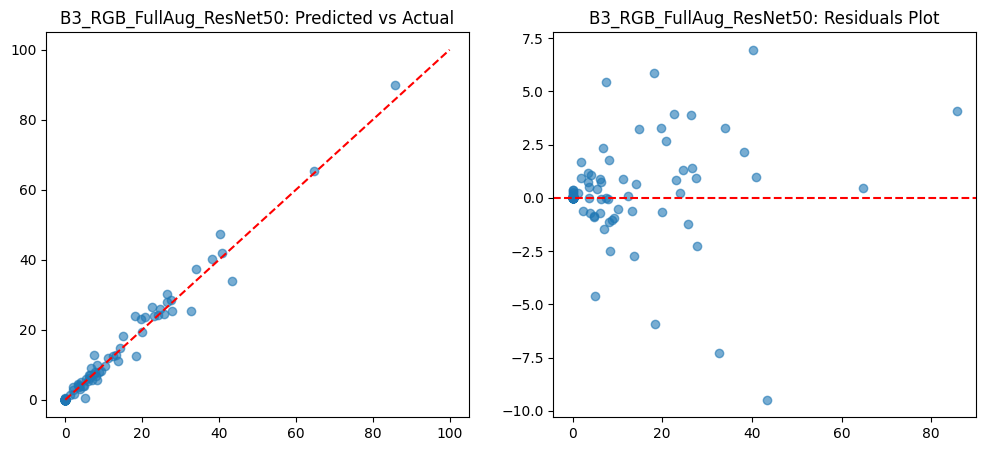

In [7]:
# Execute Experiments sequentially
B1 = run_experiment("B1_RGB_NoAug_ResNet50", "resnet50", get_no_aug_transform(), False)
B2 = run_experiment("B2_RGB_Geometric_ResNet50", "resnet50", get_geometric_transform(), False)
B3 = run_experiment("B3_RGB_FullAug_ResNet50", "resnet50", get_full_train_transform(), False)
B4 = run_experiment("B4_LeafMasked_FullAug_ResNet50", "resnet50", get_full_train_transform(), True)
B5 = run_experiment("B5_RGB_FullAug_EfficientNetB0", "efficientnet_b0", get_full_train_transform(), False)

# Summary Comparison
results_df = pd.DataFrame([{"Experiment": exp["name"], **exp["metrics"]} for exp in [B1, B2, B3, B4, B5]])
results_df = results_df.sort_values("MAE")
print("\n--- EXPERIMENT RESULTS ---")
print(results_df.to_string(index=False))

# Plot Residuals Helper
def plot_analysis(result):
    y_true, y_pred = result["y_true"], np.clip(result["y_pred"], 0, 100)
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].scatter(y_true, y_pred, alpha=0.6)
    axes[0].plot([0, 100], [0, 100], "--r")
    axes[0].set_title(f"{result['name']}: Predicted vs Actual")

    axes[1].scatter(y_true, y_pred - y_true, alpha=0.6)
    axes[1].axhline(0, color="r", linestyle="--")
    axes[1].set_title(f"{result['name']}: Residuals Plot")
    plt.show()

plot_analysis(B3)

# **Cell 6: Test-Time Augmentation (B6) & Diagnostic Analysis**

In [8]:
# TTA Definitions
def get_tta_transforms():
    return [
        A.Compose([A.Resize(IMG_SIZE, IMG_SIZE), A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD), ToTensorV2()]),
        A.Compose([A.Resize(IMG_SIZE, IMG_SIZE), A.HorizontalFlip(p=1.0), A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD), ToTensorV2()]),
        A.Compose([A.Resize(IMG_SIZE, IMG_SIZE), A.VerticalFlip(p=1.0), A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD), ToTensorV2()]),
        A.Compose([A.Resize(IMG_SIZE, IMG_SIZE), A.Rotate(limit=(10, 10), border_mode=cv2.BORDER_REFLECT_101, p=1.0), A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD), ToTensorV2()])
    ]

class TTADataset(Dataset):
    def __init__(self, dataframe, transform, leaf_masked=False):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.leaf_masked = leaf_masked

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = cv2.cvtColor(cv2.imread(row["image_file"]), cv2.COLOR_BGR2RGB)
        leaf = (cv2.imread(row["leaf_mask_file"], cv2.IMREAD_GRAYSCALE) > 127).astype(np.uint8) * 255

        transformed = self.transform(image=image, mask=leaf)
        img_t, mask_t = transformed["image"], (transformed["mask"] > 127).float()

        if self.leaf_masked: img_t = img_t * mask_t.unsqueeze(0)
        return {"image": img_t, "severity": torch.tensor(float(row["severity_percent"]), dtype=torch.float32)}

@torch.no_grad()
def tta_predict(model, dataframe, leaf_masked=False):
    model.eval()
    predictions_all = []
    for transform in get_tta_transforms():
        dataset = TTADataset(dataframe, transform=transform, leaf_masked=leaf_masked)
        loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
        preds = []
        for batch in loader:
            preds.extend(model(batch["image"].to(DEVICE, non_blocking=True)).cpu().numpy())
        predictions_all.append(np.array(preds))
    return np.stack(predictions_all, axis=0).mean(axis=0)

# Run B6 on Top Model (Assume B3)
best_model = B3["model"]
tta_pred = tta_predict(best_model, test_df, leaf_masked=False)
tta_metrics = calculate_metrics(B3["y_true"], tta_pred)

print("\n--- B6 TTA RESULTS ---")
for k, v in tta_metrics.items(): print(f"{k:10s}: {v:.4f}")

# Severity Bin & Disease Analysis
def severity_bin_analysis(y_true, y_pred):
    bins, labels = [-0.01, 1, 5, 10, 20, 40, 60, 100], ["0–1", "1–5", "5–10", "10–20", "20–40", "40–60", "60–100"]
    temp = pd.DataFrame({"true": y_true, "pred": np.clip(y_pred, 0, 100)})
    temp["severity_bin"] = pd.cut(temp["true"], bins=bins, labels=labels)

    rows = []
    for bin_name, group in temp.groupby("severity_bin", observed=False):
        if len(group) == 0: continue
        rows.append({"Bin": str(bin_name), "N": len(group), "MAE": mean_absolute_error(group["true"], group["pred"])})
    return pd.DataFrame(rows)

print("\n--- SEVERITY BIN METRICS ---")
print(severity_bin_analysis(B3["y_true"], B3["y_pred"]).to_string(index=False))


--- B6 TTA RESULTS ---
MAE       : 0.9873
RMSE      : 1.8785
R2        : 0.9828
Pearson   : 0.9925
Spearman  : 0.9583

--- SEVERITY BIN METRICS ---
   Bin  N      MAE
   0–1 49 0.037107
   1–5 12 0.781639
  5–10 16 1.506564
 10–20 10 2.372562
 20–40 14 2.289435
 40–60  3 5.806393
60–100  2 2.283947
